# **Complete repository step-by-step diagnostics.**

In [1]:
from typing import Callable, Any, Optional
from rich import print 

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as e:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(e).__name__}({e})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(e).__name__}({e})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        else:
            print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
            return result
        
def mock_division(a, b):
    if not isinstance(b, (int, float)):
        raise TypeError("Denominator must be numeric.")
    return a / b

print("--- LOGGING STATE SHOWCASE ---")

validate_call("Standard Math", True, mock_division, 10, 2)
validate_call("String Input", False, mock_division, 10, "five")
validate_call("Divide by Zero", True, mock_division, 10, 0)
validate_call("Flawed Assumption", False, mock_division, 10, 5)

--- LOGGING STATE SHOWCASE ---

[VALIDATED] Standard Math: Executed successfully.

[REJECTED] String Input: Safely blocked with TypeError(Denominator must be numeric.)

[EXCEPTION] Divide by Zero: Expected success but crashed with ZeroDivisionError(division by zero)

[FALSE POSITIVE] Flawed Assumption: Expected rejection but execution succeeded.

2.0

## **Node** (in node.py)

--- NODE TESTS ---

[VALIDATED] Node(124.2, 8.2, 0): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 1): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 2): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 3): Executed successfully.

...

[REJECTED] Node(181, 8.2, 0): Safely blocked with ValueError([NODE] Invalid lon value 181. Must be a number from 
-180 to 180.)

[REJECTED] Node(-181, 8.2, 0): Safely blocked with ValueError([NODE] Invalid lon value -181. Must be a number from 
-180 to 180.)

[REJECTED] Node(124.2, 91, 0): Safely blocked with ValueError([NODE] Invalid lat value 91. Must be a number from 
-90 to 90.)

[REJECTED] Node(124.2, -91, 0): Safely blocked with ValueError([NODE] Invalid lat value -91. Must be a number from 
-90 to 90.)

--- VISUALIZATION TEST ---

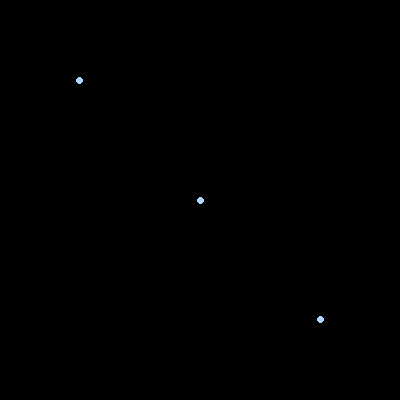

In [2]:
from utils.node import Node
from PIL import Image
from IPython.display import display

print("--- NODE TESTS ---")

# Valid construction
test_node_configs = [
    (124.2, 8.2, 0, True),
    (124.2, 8.2, 1, True),
    (124.2, 8.2, 2, True),
    (124.2, 8.2, 3, True),
    (124.2, 8.2, None, True),
]

for lon, lat, layer, expected in test_node_configs:
    label = f"Node({lon}, {lat}, {layer})"
    if layer is None:
        node = validate_call(label, expected, Node, lon, lat)
    else:
        node = validate_call(label, expected, Node, lon, lat, layer)

# Invalid layer values
invalid_layer_configs = [
    (124.2, 8.2, 4),
    (124.2, 8.2, -1),
]

for lon, lat, layer in invalid_layer_configs:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

# Invalid coordinates
invalid_coord_configs = [
    (181, 8.2, 0),
    (-181, 8.2, 0),
    (124.2, 91, 0),
    (124.2, -91, 0),
]

for lon, lat, layer in invalid_coord_configs:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

# Immutability + unique IDs
n1 = Node(124.2, 8.2, 0)
n2 = Node(124.2, 8.2, 0)

assert n1.id != n2.id, "Node IDs should be unique"
assert isinstance(n1.id, str) and n1.id.startswith("N"), "Node ID should be a string"
assert n1.lon == 124.2 and n1.lat == 8.2, "Node coordinates should be preserved"

try:
    n1.lon = 125.0
    raise AssertionError("Node.lon should be immutable")
except AttributeError:
    pass

try:
    n1.lat = 9.0
    raise AssertionError("Node.lat should be immutable")
except AttributeError:
    pass

print("\n--- VISUALIZATION TEST ---")
img_node = Image.new("RGB", (400, 400), "black")
context = ((124.20, 8.30), (124.30, 8.20))
vis_nodes = [
    Node(124.22, 8.28, 0),
    Node(124.28, 8.22, 1),
    Node(124.25, 8.25, 2)
]
for n in vis_nodes:
    n.draw(context, img_node)
display(img_node)


## **DirEdge** (in directed_edge.py)

--- DIR EDGE CONFIG TESTS ---

[VALIDATED] DirEdge(Node(N9e233aaa898841b194ab0c67284ad870): lon=124.2384, lat=8.2393, layer=1, 
Node(Nd18c923f98fa42ce877efdeed6b25bc0): lon=124.243862, lat=8.237768, layer=1): Executed successfully.

[REJECTED] DirEdge(None, Node(Nd18c923f98fa42ce877efdeed6b25bc0): lon=124.243862, lat=8.237768, layer=1): Safely 
blocked with ValueError([DIR EDGE] No start node provided.)

[REJECTED] DirEdge(Node(N9e233aaa898841b194ab0c67284ad870): lon=124.2384, lat=8.2393, layer=1, None): Safely 
blocked with ValueError([DIR EDGE] No end node provided.)

[REJECTED] DirEdge(Node(N9e233aaa898841b194ab0c67284ad870): lon=124.2384, lat=8.2393, layer=1, 
Node(N9e233aaa898841b194ab0c67284ad870): lon=124.2384, lat=8.2393, layer=1): Safely blocked with ValueError([DIR 
EDGE] Start and end nodes cannot be identical.)

...

[VALIDATED] DirEdge(Node(N9e233aaa898841b194ab0c67284ad870): lon=124.2384, lat=8.2393, layer=1, 
Node(Nd18c923f98fa42ce877efdeed6b25bc0): lon=124.243862, lat=8.237768, layer=1): Executed successfully.

Type: start_walk

[REJECTED] DirEdge(Node(Nf048b72374d44a4cab58096aa550cc15): lon=124.2384, lat=8.2393, layer=3, 
Node(Nf048b72374d44a4cab58096aa550cc15): lon=124.2384, lat=8.2393, layer=3): Safely blocked with ValueError([DIR 
EDGE] Start and end nodes cannot be identical.)

[REJECTED] DirEdge(Node(N9e233aaa898841b194ab0c67284ad870): lon=124.2384, lat=8.2393, layer=1, 
Node(N109e02d855e14115a18f08ae939eea91): lon=124.243862, lat=8.237768, layer=0): Safely blocked with 
ValueError([DIR EDGE] Start and end nodes on different layers must have same coordinates.)

--- VISUALIZATION TEST ---

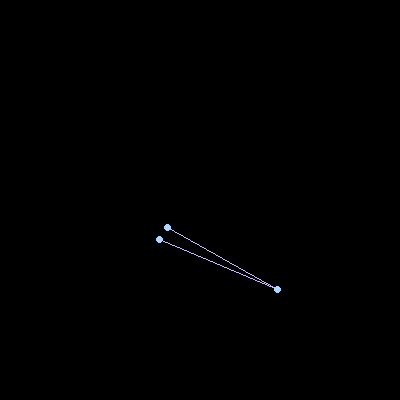

In [3]:
from utils.node import Node
from utils.directed_edge import DirEdge, _stitch
from PIL import Image
from IPython.display import display

n1l1 = Node(124.2384, 8.2393, 1) 
n2l1 = Node(124.243862, 8.237768, 1) 
n3l1 = Node(124.238, 8.239, 1) 

n1l2 = Node(124.2384, 8.2393, 2)
n2l2 = Node(124.243862, 8.237768, 2)
n3l2 = Node(124.238, 8.239, 2)

n1l3 = Node(124.2384, 8.2393, 3)
n2l3 = Node(124.243862, 8.237768, 3)
n3l3 = Node(124.238, 8.239, 3)

n1l0 = Node(124.2384, 8.2393, 0)
n2l0 = Node(124.243862, 8.237768, 0)
n3l0 = Node(124.238, 8.239, 0)

test_dir_configs = [
    (n1l1, n2l1, True),
    (None, n2l1, False),
    (n1l1, None, False),
    (n1l1, n1l1, False),
    (n1l1, n2l0, False)
]

print("\n--- DIR EDGE CONFIG TESTS ---")
for config in test_dir_configs:
    start_node, end_node, expected = config
    result = validate_call(
        f"DirEdge({start_node}, {end_node})",
        expected,
        DirEdge,
        start_node,
        end_node
    )
    
print("\n--- STITCHING TEST ---")
dir_edges_s = [DirEdge(n1l1, n2l1), DirEdge(n2l1, n3l1)]
dir_edges_e = [DirEdge(n1l2, n2l2), DirEdge(n2l1, n2l2)] 
validate_call(
    "_stitch(dir_edges_s, dir_edges_e, weight=2, verbose=True)",
    True,
    _stitch,
    dir_edges_s,
    dir_edges_e,
    weight=2
)
for edge in dir_edges_s + dir_edges_e:
    print(f"{edge.id} is connected to {edge.next_edges}")

print("\n--- LENGTH TEST ---")
print("Great-Circle Distance of MSU-IIT to 7-11 MSU-IIT:")
print(DirEdge(n1l1, n2l1).getLength())

print("\n--- TYPE TEST ---")
typeTestConfigs = [
    (n1l1, n2l1, True),
    (n1l3, n1l3, False),
    (n1l1, n2l0, False),
]

for config in typeTestConfigs:
    start_node, end_node, expected = config
    dir_edge = validate_call(
        f"DirEdge({start_node}, {end_node})",
        expected,
        DirEdge,
        start_node,
        end_node
    )
    if dir_edge is not None:
        print(f"Type: {dir_edge.getType()}")

print("\n--- VISUALIZATION TEST ---")
img_edge = Image.new("RGB", (400, 400), "black")
context_edge = ((124.230, 8.245), (124.250, 8.235))

vis_e1 = DirEdge(n1l1, n2l1)
vis_e2 = DirEdge(n2l1, n3l1)

vis_e1.draw(context_edge, img_edge)
vis_e2.draw(context_edge, img_edge)

# Draw nodes on top to verify alignment
n1l1.draw(context_edge, img_edge)
n2l1.draw(context_edge, img_edge)
n3l1.draw(context_edge, img_edge)

display(img_edge)

## **CityGraph** (in city_graph.py)

--- CITY GRAPH TEST FOR ILIGAN ---

[CITY GRAPH] Extracting graph offline from PBF file.


c:\Users\lifei\OneDrive\Desktop\Portfolio\Jeepney-Route-System-Optimization\.venv\Lib\site-packages\pyrosm\pyrosm.py:109: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  nodes, ways, relations, node_coordinates = parse_osm_data(
c:\Users\lifei\OneDrive\Desktop\Portfolio\Jeepney-Route-System-Optimization\.venv\Lib\site-packages\pyrosm\pyrosm.py:109: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never wo

[CITY GRAPH] Snapping explicit coordinates to network.


[VALIDATED] CityGraph initialization: Executed successfully.

CityGraph(Iligan Sector) | Nodes: 36866 | Edges: 76310 (Drivable: 26024) | Landmarks: 2

--- VISUALIZATION TESTS ---

[VALIDATED] Render full topological map: Executed successfully.

[VALIDATED] Overlay landmarks: Executed successfully.

Full Map (Arterials in Black, Dead-ends in Gray):

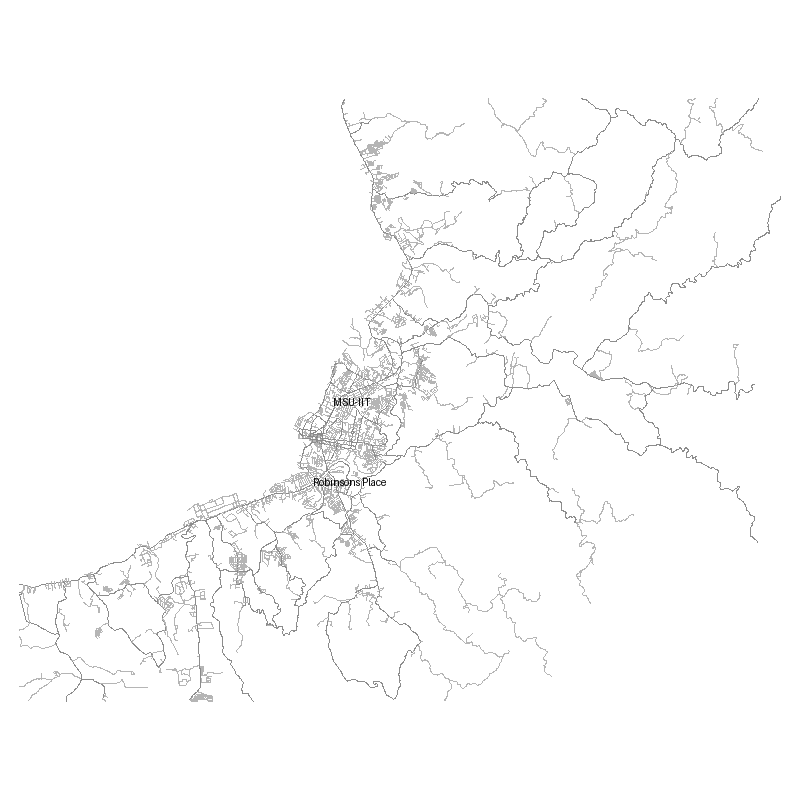

[VALIDATED] Render pruned arterial map: Executed successfully.

[VALIDATED] Overlay landmarks: Executed successfully.

Pruned Map (Strict Jeepney Corridors):

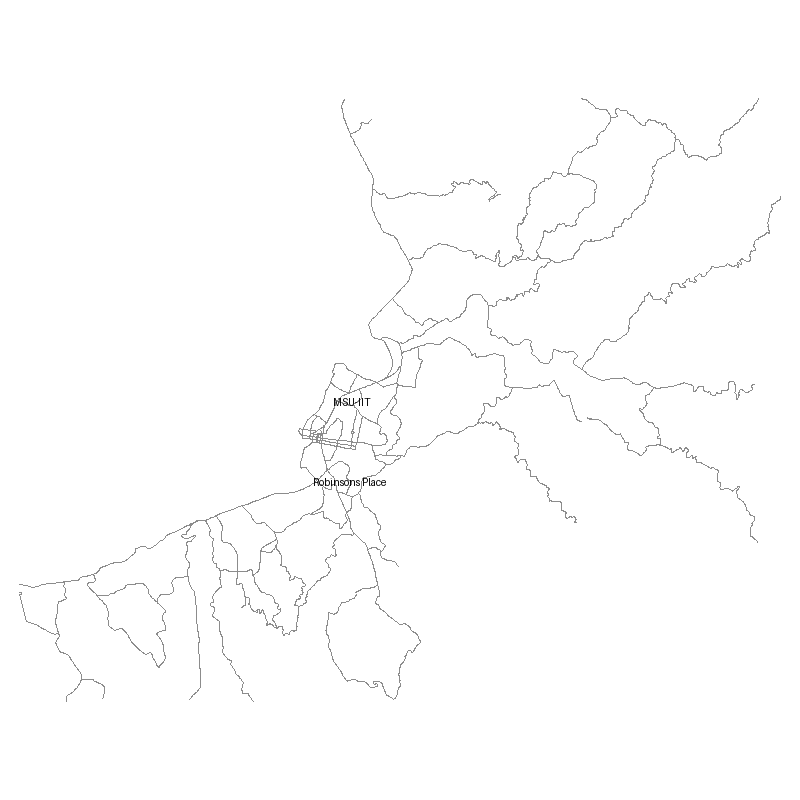

In [ ]:
from utils.city_graph import CityGraph
from IPython.display import display

print("--- CITY GRAPH TEST FOR ILIGAN ---")

# Modify coordinates to match your active sector partitioning
target_bbox = (8.1500, 8.3300, 124.1500, 124.4000)
explicit_coords = {
    "MSU-IIT": (8.2415, 124.2435),
    "Robinsons Place": (8.2175, 124.2380)
}

city = validate_call(
    "CityGraph initialization", 
    True, 
    CityGraph, 
    bbox=target_bbox,
    name="Iligan Sector",
    landmarks=explicit_coords,
    pbf_path="utils/data/iligan-city.pbf",
    verbose=True
)

if city:
    print(str(city))
    
    print("\n--- VISUALIZATION TESTS ---")
    
    img_all, context = validate_call("Render full topological map", True, city.draw, size=800, only_drivable=False)
    if img_all:
        validate_call("Overlay landmarks", True, city.draw_landmarks, context, img_all)
        print("\nFull Map (Arterials in Black, Dead-ends in Gray):")
        display(img_all)
        
    img_pruned, _ = validate_call("Render pruned arterial map", True, city.draw, size=800, only_drivable=True)
    if img_pruned:
        validate_call("Overlay landmarks", True, city.draw_landmarks, context, img_pruned)
        print("\nPruned Map (Strict Jeepney Corridors):")
        display(img_pruned)

## **DirectDemandSampler** (in direct_demand_sampler.py)

In [6]:
# prepare .env

import os
from dotenv import load_dotenv

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

if not TOMTOM_API_KEY:
    raise ValueError("[ENVIRONMENT] TOMTOM_API_KEY is missing from the .env file.")
else:
    print("[ENVIRONMENT] TOMTOM_API_KEY found")

[ENVIRONMENT] TOMTOM_API_KEY found

In [2]:
# initialize citygraph

from utils.city_graph import CityGraph
from IPython.display import display
from rich import print

print("--- 1. CITY GRAPH INITIALIZATION ---")

full_network_bbox = (8.1500, 8.3300, 124.1500, 124.4000)
explicit_coords = {
    "MSU-IIT": (8.2415, 124.2435),
    "Robinsons Place": (8.2175, 124.2380)
}

city = validate_call(
    "CityGraph initialization", 
    True, 
    CityGraph, 
    bbox=full_network_bbox,
    name="Iligan Full Sector",
    landmarks=explicit_coords,
    pbf_path="utils/data/iligan-city.pbf",
    verbose=True
)

if city:
    total_nodes = len(city.nodes)
    print(f"\n[SUCCESS] CityGraph built. Total nodes integrated: {total_nodes}")
else:
    print("\n[TERMINATED] CityGraph failed to initialize.")

--- 1. CITY GRAPH INITIALIZATION ---

[CITY GRAPH] Loading graph from binary cache.


Mapping outgoing edges: 100%|██████████| 76310/76310 [00:00<00:00, 1498267.24it/s]

[CITY GRAPH] Snapping explicit coordinates to network.


[VALIDATED] CityGraph initialization: Executed successfully.

[SUCCESS] CityGraph built. Total nodes integrated: 36866

### Spatial Topology and API Token Economy

The base road network is parsed into a directed multi-graph. To execute inverse distance weighting on empirical TomTom traffic data without exhausting API quotas, we calculate a statistically valid sample size dynamically using Cochran's formula.

To achieve a 95% confidence level with a 5% margin of error across the finite population of total network nodes, the initial sample size $n_0$ is calculated as:

$$n_0 = \frac{Z^2 p q}{e^2}$$

Where $Z = 1.96$ (95% confidence level), $p = 0.5$ (maximum population variance), and $e = 0.05$ (5% acceptable margin of error). This yields $n_0 = 384$. 

Applying the finite population correction for the dynamically retrieved node count $N$:

$$n = \frac{n_0}{1 + \frac{n_0 - 1}{N}}$$

The subsequent cell computes this exact value $n$ to restrict the API limits automatically, ensuring representative spatial accuracy while preserving transaction tokens.

*Source:* Cochran, W. G. (1977). *Sampling Techniques* (3rd ed.). John Wiley & Sons.

In [ ]:
"""
This code was run at 1PM on May 11, 2026, Monday.
This traffic data will be representative of this specific time slot.
"""


import math
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig

print("--- 2. DYNAMIC SAMPLING & VISUALIZATION ---")

if 'city' in locals() and city is not None:
    N = len(city.nodes)
    Z = 1.96
    p = 0.5
    e = 0.05
    q = 1.0 - p
    
    n_0 = ((Z ** 2) * p * q) / (e ** 2)
    optimal_sample_size = math.ceil(n_0 / (1 + ((n_0 - 1) / N)))
    
    print(f"[STATISTICS] Total Nodes (N): {N}")
    print(f"[STATISTICS] Calculated Optimal Sample Size (n): {optimal_sample_size}")

    temporal_config = DDMConfig(cache_dir="utils/.cache/1PM_traffic")

    sampler = validate_call(
        "DDM Sampler Initialization",
        True,
        DirectDemandSampler,
        city=city,
        config=temporal_config,
        api_sample_limit=optimal_sample_size, 
        only_drivable=False,
        verbose=True
    )

    if sampler:
        img_map, context = validate_call("Render base map", True, city.draw, size=800, only_drivable=False)
        
        if img_map:
            validate_call("Overlay density heat map", True, sampler.draw_density, img_map, context, num_points=5000)
            validate_call("Overlay landmarks", True, city.draw_landmarks, context, img_map)
            display(img_map)
else:
    print("[ERROR] 'city' variable not found. Execute the CityGraph initialization cell first.")

--- 2. DYNAMIC SAMPLING & VISUALIZATION ---

[STATISTICS] Total Nodes (N): 36866

[STATISTICS] Calculated Optimal Sample Size (n): 381

[DIRECT DEMAND] Computing betweenness centrality approximation.

KeyboardInterrupt: 